# GRÁFICA DE DISTRIBUCIÓN DE ENERGÍA POR CONTINENTE

In [20]:
import pandas as pd
import numpy as np

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from prophet.plot import plot_cross_validation_metric

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:


# Create a continent mapping
continent_map = {
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Cote d\'Ivoire', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei Darussalam', 'Cambodia', 'China', 'Cyprus', 'Georgia', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia','Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Taiwan', 'Tajikistan', 'Thailand', 'Timor-Leste', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'North America': ['Canada', 'Greenland', 'Mexico', 'United States'],
    'Oceania': ['Australia', 'Fiji', 'New Zealand', 'Papua New Guinea'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
}


In [6]:
dataset = pd.read_csv ("World Energy Consumption.csv")

In [7]:
col_electricity = ['low_carbon_electricity',
            'nuclear_electricity',
            'oil_electricity',
            'other_renewable_electricity',
            'other_renewable_exc_biofuel_electricity',
            'solar_electricity',
            'wind_electricity',
            'fossil_electricity',
            'gas_electricity',
            'hydro_electricity',
            'biofuel_electricity',
            'coal_electricity']
col_cons =['biofuel_consumption',
           'coal_consumption',
           'fossil_fuel_consumption',
           'gas_consumption',
           'hydro_consumption',
           'low_carbon_consumption',
           'nuclear_consumption',
           'oil_consumption',
           'solar_consumption']

In [17]:
#segundo dataframe que incluye columna con datos de consumo / dato exogeno

dataset_exog_1= dataset.groupby(['year','country'])[col_electricity].sum().sum(axis=1).to_frame('electricity_generation').reset_index("country")
dataset_exog_2 = dataset.groupby(["year", "country"])[col_cons].sum().sum(axis=1).to_frame('electricty_consumption').reset_index('country')

dataset_exog_3= pd.merge(dataset_exog_1, dataset_exog_2, on=['year', 'country'])

dataset_exog_3['continent'] = dataset_exog_3['country'].map(lambda x: next((k for k, v in continent_map.items() if x in v), None))
dataset_exog = dataset_exog_3[dataset_exog_3['continent'].notna()]

data_1986 = dataset_exog[dataset_exog.index>1985].reset_index()

In [19]:
dataset_exog_1

,country,electricity_generation
year,,
1900,Afghanistan,0.000
1900,Africa,0.000
1900,Africa (Shift),0.000
1900,Albania,0.000
1900,Algeria,0.000
...,...,...
2022,Vietnam,527.021
2022,Western Africa (EI),55.687
2022,World,57832.830


In [9]:
data_1986.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5657 entries, 0 to 5656
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    5657 non-null   int64  
 1   country                 5657 non-null   object 
 2   electricity_generation  5657 non-null   float64
 3   electricty_consumption  5657 non-null   float64
 4   continent               5657 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 221.1+ KB


In [10]:
data_1986.groupby('country')['electricity_generation'].sum().sort_values(ascending=False).head(15)

country
United States     281111.644
China             239240.606
Japan              72269.952
Russia             71091.008
India              60529.817
Germany            43876.374
Canada             43155.912
France             38081.248
Brazil             30964.994
United Kingdom     26126.157
South Korea        25694.850
Italy              19986.694
Spain              17265.238
Mexico             16588.304
South Africa       15469.888
Name: electricity_generation, dtype: float64

## Prophet por pais o continente

<AxesSubplot:>

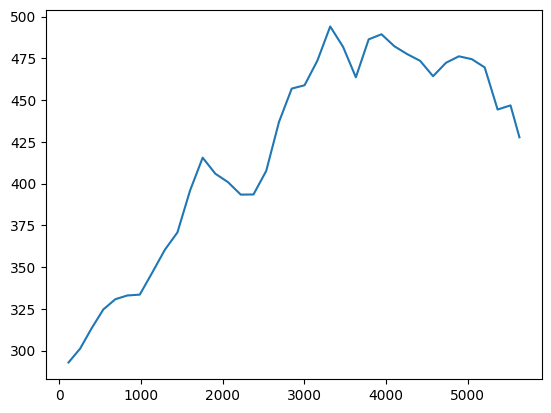

In [11]:
data_1986[data_1986['country']=='South Africa']['electricity_generation'].plot()

## Funcion Prophet con pruebas de impresion usando Plotly

In [12]:
def data_lugar (dato,lugar):
    if lugar in dato['continent'].values:
        dato = dato.groupby(['year','continent'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['continent']==lugar]
        print(dato)
    elif lugar in dato['country'].values:
        dato = dato.groupby(['year','country'])[['electricity_generation', 'electricty_consumption']].sum().reset_index()
        dato = dato[dato['country']==lugar]
        print(dato)
    else:
        return None
    return dato

In [ ]:

def prophet(dato,lugar):
    dato= data_lugar(dato,lugar)
    # Crear una copia temporal de los datos
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']

    #prophet_data['electricty_consumption'] = prophet_data['electricty_consumption']

    # Definir la grilla de parámetros para optimización
    param_grid = {
        'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1],
        'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }

    # Generar todas las combinaciones de parámetros
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    rmses = []

    # Usar el 70% de los datos para entrenamiento
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data.iloc[:train_size]
    test_data = prophet_data.iloc[train_size:]

    print("Finding best parameters...")
    best_rmse = float('inf')
    best_params = None

    for params in all_params:
        # Crear y ajustar el modelo con cada combinación de parámetros
        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            seasonality_mode=params['seasonality_mode']
        )
        model.add_regressor('electricty_consumption')
        model.fit(train_data)

        # Generar el dataframe futuro para el periodo de test
        future = model.make_future_dataframe(periods=len(test_data), freq='Y')
        # Incorporar la variable externa en el futuro
        future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
        # Rellenar valores faltantes (por ejemplo, usando el último valor observado)
        future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

        forecast = model.predict(future)

        # Calcular el error para el periodo de test
        test_predictions = forecast.iloc[-len(test_data):]
        rmse = np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat']))
        rmses.append(rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"{param}: {value}")
    print(f"Best RMSE: {best_rmse:.2f}")

    # Ajustar el modelo final con los mejores parámetros
    final_model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )
    final_model.add_regressor('electricty_consumption')
    final_model.fit(prophet_data)

    # Crear el dataframe futuro para 5 periodos adicionales
    future = final_model.make_future_dataframe(periods=5, freq='Y')
    # Incorporar el regressor en el dataframe futuro
    future = future.merge(prophet_data[['ds', 'electricty_consumption']], on='ds', how='left')
    future['electricty_consumption'] = future['electricty_consumption'].fillna(method='ffill')

    forecast = final_model.predict(future)

    fig = go.Figure()

    ultima_fecha = prophet_data['ds'].max()

    # Filtra el dataframe de forecast para obtener solo las fechas posteriores a la última de los datos reales
    forecast_pred = forecast[forecast['ds'] >= ultima_fecha]

    # Traza los datos reales (puedes asignar el color que prefieras)
    fig.add_trace(go.Scatter(
        x=prophet_data['ds'],
        y=prophet_data['y'],
        mode='lines',
        name="Datos reales",
        line=dict(color='blue')  # Color para los datos reales
    ))

    # Traza la predicción solo para el tramo futuro y en color rojo
    fig.add_trace(go.Scatter(
        x=forecast_pred['ds'],
        y=forecast_pred['yhat'],
        mode='lines',
        name="Predicción",
        line=dict(color='red')  # La predicción se mostrará en rojo
    ))



# Etiquetas y diseño
    fig.update_layout(width=900,height=700,
    title=f"Predicción de Generación de Electricidad con Prophet {lugar}",
    xaxis_title="Año",
    yaxis_title="Generación de electricidad",
    template="plotly_white"
    )


    fig.show()

# Print additional metrics for test set
    mae = mean_absolute_error(test_data['y'], test_predictions['yhat'])
    mape = np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100

    f_cv = cross_validation(final_model, initial='730 days', period='365 days', horizon='365 days')
    #print(f_cv)

    print("\nTest Set Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {best_rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    df_p = performance_metrics(f_cv)
    print(df_p.head(10))
    fig = plot_cross_validation_metric(f_cv, metric='mape')


    '''
# Datos reales
    fig.add_trace(go.Scatter(x=prophet_data['ds'], y=prophet_data['y'],
                          mode='lines', name="Datos reales",
                          line=dict(color='red')))

# Predicción
    fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'],
                         mode='lines', name="Predicción",
                         line=dict(color='blue')))

# Intervalo de confianza
    #fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'],
     #                    mode='lines', name="Límite superior",
      #                   line=dict(color='blue', width=0),
       #                  showlegend=False))
    #fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'],
    #                     mode='lines', name="Límite inferior",
     #                    line=dict(color='blue', width=0),
     #                    fill='tonexty', fillcolor='rgba(0,0,255,0.2)',
     #                    showlegend=True))

'''

13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:56 - cmdstanpy - INFO - Chain [1] done processing


      year country  electricity_generation  electricty_consumption
26    1986   China                 899.060               12888.212
168   1987   China                 994.534               13900.479
310   1988   China                1090.420               14934.225
452   1989   China                1169.620               15672.874
594   1990   China                1242.400               15876.308
741   1991   China                1355.100               16675.010
890   1992   China                1507.880               17546.705
1043  1993   China                1623.178               18914.305
1196  1994   China                1855.590               20095.059
1350  1995   China                2014.058               20693.912
1504  1996   China                2162.614               21809.765
1658  1997   China                2271.095               21953.030
1813  1998   China                2333.996               21992.203
1968  1999   China                2478.596               22762

13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:56 - cmdstanpy - INFO - Chain [1] done processing
13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:56 - cmdstanpy - INFO - Chain [1] done processing
13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:56 - cmdstanpy - INFO - Chain [1] done processing
13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:56 - cmdstanpy - INFO - Chain [1] done processing
13:02:56 - cmdstanpy - INFO - Chain [1] start processing
13:02:57 - cmdstanpy - INFO - Chain [1] done processing
13:02:57 - cmdstanpy - INFO - Chain [1] start processing
13:02:57 - cmdstanpy - INFO - Chain [1] done processing
13:02:57 - cmdstanpy - INFO - Chain [1] start processing
13:02:57 - cmdstanpy - INFO - Chain [1] done processing
13:02:57 - cmdstanpy - INFO - Chain [1] start processing
13:02:57 - cmdstanpy - INFO - Chain [1] done processing
13:02:57 - cmdstanpy - INFO - Chain [1] start processing
13:02:57 - cmdstanpy - INFO - Chain [1]


Best parameters:
changepoint_prior_scale: 0.01
seasonality_prior_scale: 10.0
seasonality_mode: multiplicative
Best RMSE: 2838.10


13:03:04 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/34 [00:00<?, ?it/s]

13:03:04 - cmdstanpy - INFO - Chain [1] start processing
13:03:07 - cmdstanpy - INFO - Chain [1] done processing
13:03:07 - cmdstanpy - INFO - Chain [1] start processing
13:03:08 - cmdstanpy - INFO - Chain [1] done processing
13:03:08 - cmdstanpy - INFO - Chain [1] start processing
13:03:09 - cmdstanpy - INFO - Chain [1] done processing
13:03:09 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1] done processing
13:03:12 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1] done processing
13:03:12 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1] done processing
13:03:12 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1] done processing
13:03:12 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1] done processing
13:03:12 - cmdstanpy - INFO - Chain [1] start processing
13:03:12 - cmdstanpy - INFO - Chain [1]


Test Set Metrics:
MAE: 3460.15
RMSE: 2838.10
MAPE: nan%
   horizon           mse        rmse         mae      mape     mdape  \
0 357 days  10876.533387  104.290620   69.292145  0.056768  0.020246   
1 358 days   3295.167326   57.403548   51.020383  0.027339  0.026131   
2 359 days   3528.719383   59.403025   46.257186  0.019039  0.015992   
3 360 days  14811.803265  121.703752  116.189536  0.031394  0.031117   
4 361 days  32922.439895  181.445419  169.312063  0.027254  0.027006   
5 362 days  44807.082776  211.676836  191.805183  0.022565  0.018855   
6 363 days  17520.430734  132.364764  111.699171  0.009922  0.009919   
7 364 days  57905.317010  240.635236  218.367646  0.014699  0.013774   
8 365 days  33603.557412  183.312731  142.517471  0.008806  0.011601   

      smape  coverage  
0  0.060979  0.000000  
1  0.027825  0.250000  
2  0.019336  0.500000  
3  0.031122  0.000000  
4  0.027514  0.000000  
5  0.022849  0.000000  
6  0.009994  0.500000  
7  0.014647  0.250000  
8  0.0

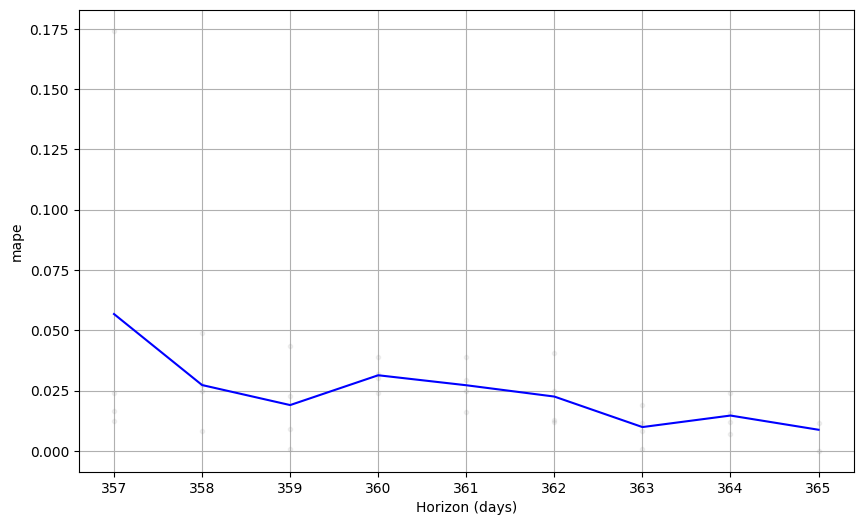

In [41]:
lugar='China'
prophet(data_1986,lugar)


In [ ]:
def plot_energy_distribution(data,lugar:
    # Asignar continente a cada país según un diccionario (continent_map)
    data['continente'] = data['country'].map(
        lambda x: next((k for k, v in continent_map.items() if x in v), None)
    )
    df_continente = data[data['continente'] == continente]

    # Agrupar y filtrar datos (se asume que 'col_electricity' y 'rename_columns' ya están definidos)
    df_continente = df_continente.groupby(['year', 'continente'])[col_electricity].sum().reset_index('continente')
    df_continente = df_continente[df_continente.index.year > 1970]

    # Crear variables adicionales
    df_continente['carbon'] = df_continente['low_carbon_electricity'] + df_continente['coal_electricity']
    df_continente['renovable'] = df_continente['other_renewable_electricity'] + df_continente['other_renewable_exc_biofuel_electricity']
    df_continente.drop(
        columns=['low_carbon_electricity', 'other_renewable_electricity',
                 'other_renewable_exc_biofuel_electricity', 'coal_electricity'],
        inplace=True
    )
    df_continente.rename(columns=rename_columns, inplace=True)

    energy_sources = ['nuclear', 'petroleo', 'solar', 'eolica', 'fosil',
                        'gas', 'hidro', 'bio fuel', 'carbon', 'renovable']

    # Crear figura con dos subplots: uno para evolución (línea) y otro para distribución (donut)
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'Evolución de la producción de energía en {continente}',
                        f'Distribución Energía {continente}'),
        specs=[[{"type": "xy"}, {"type": "domain"}]]
    )

    # Agregar trazas para la evolución de la producción (línea)
    for source in energy_sources:
        fig.add_trace(
            go.Scatter(
                x=df_continente.index.year,
                y=df_continente[source],
                mode='lines+markers',
                name=source
            ),
            row=1, col=1
        )

    # Calcular totales y porcentajes para el gráfico de pastel
    totals = df_continente[energy_sources].sum()
    porcentajes = (totals / totals.sum()) * 100

    # Agregar la traza de pastel (donut)
    fig.add_trace(
        go.Pie(
            labels=totals.index,
            values=porcentajes,
            hole=0.5,
            textinfo='percent+label'
        ),
        row=1, col=2
    )

    # Ajustar el layout
    #fig.update_layout(margin=dict(t=50, b=0, l=0, r=0))
    fig.update_layout(width=1000,margin=dict(t=50, b=0, l=0, r=0))
    return fig


In [ ]:
plot_energy_distribution(dataset,lugar)

NameError: name 'dato' is not defined